# Tool 호출 루프가 있는 LangGraph Chatbot

일반 Chat Model은 질문을 읽고 답변을 한 번 생성한다. Tool이 연결된 Chat Model은 답변에 외부 정보가 필요하면 검색이나 계산 같은 기능의 **실행 요청**을 만들 수 있다.

모델이 Tool을 직접 실행하는 것은 아니다. <br>
모델은 `AIMessage.tool_calls`를 만들고, LangGraph의 Tool Node가 요청을 실행해 `ToolMessage`로 돌려준다. <br>
모델은 그 결과를 다시 읽고 최종 답변을 만들거나 다른 Tool을 요청한다.


## 패키지 설치

Tool loop에 필요한 LangGraph, OpenAI와 Tavily 통합을 설치한다. 이 셀은 외부 검색이나 유료 모델을 호출하지 않는다.


In [1]:
from multiprocessing.connection import answer_challenge

from torch.utils._sympy import printers
from transformers import VaultGemmaModel
%pip install -U langgraph langchain-openai langchain-tavily python-dotenv


Note: you may need to restart the kernel to use updated packages.


## OpenAI와 Tavily 인증 준비

`.env` 또는 운영체제 환경 변수에서 필수 키를 불러온다. 값 자체는 출력하지 않고, LangSmith가 없을 때도 그래프의 핵심 경로는 유지한다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-tool-chat")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## Tavily Tool의 입력과 반환 구조

Tavily(태빌리)는 AI 애플리케이션이 최신 웹 문서를 검색하도록 제공하는 검색 서비스이다.<br>
`TavilySearch`는 이 서비스를 LangChain Tool 형식으로 감싼 객체이다.

- `Tool`: 모델에 보여 줄 이름·설명·입력 규칙과 실제 Python 실행 기능을 함께 가진 객체이다.
- `args_schema`: Tool이 받을 수 있는 인자 이름과 자료형을 정의한 입력 스키마이다. `TavilySearch`에서는 `query` 등의 값을 검사하고, `bind_tools()`가 모델에 전달할 함수 설명의 근거가 된다.
- `invoke()` 입력: `query`가 담긴 딕셔너리이다.
- `invoke()` 출력: 검색어와 `results` 목록 등이 담긴 딕셔너리이다.

Agent에 연결하기 전에 직접 호출하면 Tavily 인증·입력 문제를 뒤의 모델 판단이나 그래프 연결 문제와 분리할 수 있다.


In [23]:
from langchain_tavily import TavilySearch

# 웹 검색 도구 (관련 내용 최대 2건 검색)
tavily_tool = TavilySearch(max_results=2)

# tavily 정상 동작 확인
tavily_tool.invoke({"query": "LangGraph에서 Node란 무엇인가?"})

{'query': 'LangGraph에서 Node란 무엇인가?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체로 정의할 수 있다.  \n   \n특징\n\n 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n 입력과 출력은 State를 기반으로 한다.\n 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 만들기\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] # 인공지능 개발자 수다\n\n인공지능 개발자 수다(유튜브 바로가기) 자세히보기\n\n자연어처리/LangGraph\n\n## [LangGraph] 노드(node)와 엣지(edge)\n\nSuda\\_777 2025. 8. 9. 22:40\n\n목차\n\n반응형\n\nlanggraph 버전: 0.6.4  \n내용 출처 : LangGrapn Docs\n\nLangGraph\n\nLangGraph Trusted by compan

## Tool 스키마를 Chat Model에 연결하기

### 호출 전에 넣는 `tools`

- `tools`: 모델이 선택할 수 있도록 전달하는 Tool 객체 목록이다.
- `bind_tools(tools)`: 각 Tool의 이름·설명·`args_schema`를 모델 요청에 포함한 새 Runnable을 만든다.

### 호출 뒤에 나오는 `tool_calls`

- `tool_calls`: 모델이 `tools`를 보고 만든 실행 요청 목록이다.
    - 이름이 비슷하지만 Tool 객체 목록이 아니라 **모델의 출력**이며, 이 단계에서는 Python Tool이 아직 실행되지 않았다.
    - 실제 실행은 뒤의 Tool Node가 맡는다.


In [5]:
from langchain_openai import ChatOpenAI

# 1. llm 모델 객체 생성
llm = ChatOpenAI(
    model = OPENAI_CHAT_MODEL,
    use_responses_api=True
)

# 2. llm에게 전달할 tool 목록 생성
tools = [tavily_tool]

# 3. llm과 tool 목록이 연결된 새 Runnable 생성
llm_with_tools = llm.bind_tools(tools)

print("llm_with_tools:", type(llm).__name__)
print("llm_with_tools:", type(llm_with_tools).__name__)

llm_with_tools: ChatOpenAI
llm_with_tools: _ChatModelBinding


### Tool 호출 루프를 완성할 네 구성 요소

여기까지 만든 `llm_with_tools`는 Tool의 이름·설명·입력 스키마를 알고 **실행 요청을 작성할 수 있는 모델**이다. `bind_tools()`는 Tool을 모델에 알려 줄 뿐 Tavily를 실행하지 않는다.

모델의 요청을 실제 실행하고 그 결과를 다시 모델에게 전달하려면 다음 네 구성 요소가 필요하다.

1. `State`: 질문·Tool 요청·Tool 결과·최종 답변을 이어 주는 공유 메시지 규칙이다.
2. `chatbot`: State를 읽어 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만드는 Node이다.
3. `ToolNode`: `tool_calls`를 읽어 실제 Tool을 실행하고 `ToolMessage`를 만드는 Node이다.
4. `tools_condition`: 최신 `AIMessage`에 Tool 요청이 있는지 보고 다음 경로를 정하는 route function이다.

```text
HumanMessage → chatbot → AIMessage → tools_condition
                         ├─ tool_calls 있음 → ToolNode → ToolMessage → chatbot
                         └─ tool_calls 없음 → END
```

다음 네 셀에서는 이 부품을 **정의만** 하므로 화면 출력이나 외부 호출이 발생하지 않는다. 뒤의 `네 구성 요소를 Tool 호출 루프로 조립하기`에서 `StateGraph`에 등록하고 `compile()`한 뒤, `graph.invoke()`를 호출할 때 하나의 반복 구조로 동작한다.

### 1. 대화 이력을 합칠 State 규칙 정의하기

`State`는 Node 사이에서 공유하는 데이터 구조이다. 이 셀에서는 메시지를 직접 저장하지 않고, 그래프 실행 중 새 message를 기존 목록에 합치는 규칙을 선언한다.

- 저장 대상: `HumanMessage`(질문), `AIMessage`(답변 또는 Tool 요청), `ToolMessage`(Tool 결과)이다.
- 실행 시 입력: 기존 `messages`와 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 두 값을 실행 순서대로 합친다.
- 출력: 다음 Node가 읽을 수 있는 갱신된 `messages`이다.
- 다음 사용처: Tool 결과가 추가된 뒤 `chatbot`이 이전 질문과 요청까지 함께 읽는다.


In [6]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages : Annotated[list[AnyMessage], add_messages]

### 2. 모델의 다음 행동을 정하는 chatbot Node 만들기

`chatbot`은 현재 State의 전체 `messages`를 `llm_with_tools`에 전달하는 Node이다. 모델은 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만들지만, 이 Node가 Tool을 직접 실행하지는 않는다.

- 입력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 현재 State이다.
- 변환: 모델이 지금 답할지 Tool 실행을 요청할지 결정한다.
- 출력: 새 `AIMessage` 하나이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

첫 호출에서는 Tool 요청을 만들 수 있고, Tool 결과가 State에 추가된 뒤 다시 호출되면 그 결과를 근거로 최종 답변을 만들 수 있다. 이 셀은 함수 정의 단계이므로 모델 API는 아직 호출하지 않는다.


In [14]:
def chatbot(state:State) -> dict:
    # State의 메시지를 tool이 묶여 있는 LLM에 전달
    # -> tool 사용 조건은 아래에서 정의할 예정
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": response}

#### 3. Tool 요청을 실제 실행하는 Tool Node 만들기

`chatbot`이 만든 `tool_calls`는 **실행 요청**일 뿐 실제 검색 결과가 아니다. `ToolNode`는 요청의 Tool 이름과 인자를 읽고 허용된 Python Tool을 실행한 뒤, 결과를 `ToolMessage`로 바꾸는 Node이다.

```text
tool_calls의 name·args·id
        ↓ 이름으로 Tool 선택
tool.invoke(args)
        ↓ 결과와 같은 호출 ID 연결
ToolMessage(content, tool_call_id=id)
```

- 입력: 최신 `AIMessage.tool_calls`의 `name`·`args`·`id`이다.
- 변환: `name`으로 허용된 Tool을 찾고 `tool.invoke(args)`로 실행한다.
- 출력: 실행 결과와 같은 호출 ID를 담은 `ToolMessage` 목록이다.
- 다음 사용처: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델로 돌려보낸다.

이 Node는 Tool 요청의 유무를 판단하지 않는다. 뒤의 `tools_condition`이 `tool_calls`가 있을 때만 이 Node로 보낸다. 내부 원리를 확인하기 위해 직접 구현하며, 노트북 마지막에는 같은 역할의 LangGraph 기본 제공 `ToolNode`로 교체한다.


In [15]:
import json

from langchain_core.messages import ToolMessage

class ToolNode:
    """AIMessage.tool_calls를
    허용된 python tool(함수) 결과로 바꾸는 Node이다.
    """

    # 1. 전달 받은 tool 목록
    #   {tool 이름 : 실제 tool 함수} 형태의 dict로 변환
    def __init__(self, tools):
        self.tools_by_name = {
            tool.name: tool for tool in tools
        }

    # 2. __call__(): 객체를 함수처럼 호출할 수 있게하는 메서드
    # ex) tool_node = ToolNode(tools)
    #     tool_node.__call__() == tool_node()
    def __call__(self, state:State):
        # 요청 읽기: state에 messages가 없으면 []
        #           있으면 마지막 message를 tool 요청으로 사용
        messages = state.get("messages", [])

        if not messages:
            raise ValueError("State에 messages가 없습니다.")

        # state의 마지막 메시지
        request_message = messages[-1]

        # 3. Tool 실행: 각 tool_calls의 name, args, id를 차례대로 처리
        outputs = [] # tool 요청 결과를 저장할 list

        for tool_call in request_message.tool_calls:
            tool_name = tool_call["name"]

            if tool_name not in self.tools_by_name:
                raise ValueError(f"허용되지 않은 Tool 요청입니다: {tool_name}")

            # args: args schema 검사를 거쳐 Tool에 입력할 값 (dict)
            tool_result = self.tools_by_name[tool_name].invoke(
                tool_call["args"]
            )

            # 4. tool 결과를 ToolMessage로 변환하여 outputs 누적
            outputs.append(
                ToolMessage(
                    # 결과를 만든 Tool 이름
                    name = tool_name,

                    # Tool 결과 (dict)를 JSON으로 변환
                    content=json.dumps(
                        tool_result,
                        ensure_ascii=False,
                    ),

                    tool_call_id = tool_call["id"]
                )
            )

            # 5. State 갱신 값을 반환
            # -> ToolNode 종료 후 add_messages가
            #    State['messages'] 제일 뒤에 outputs 추가(갱신 작업)
            return {"messages": outputs}

# 6. ToolNode 노드 생성
tool_node = ToolNode(tools)

#### 4. Tool 실행 여부를 판단하는 route function 만들기

`tools_condition`은 Conditional Edge 자체가 아니라, 현재 State를 읽고 **다음 목적지 label만 반환하는 함수**이다.

- 입력: `chatbot`이 방금 추가한 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

이 함수는 Tool을 실행하거나 State를 수정하지 않는다. 실제 Conditional Edge는 뒤에서 `add_conditional_edges()`가 반환값과 목적지를 연결할 때 만들어진다. 이 셀도 함수 정의 단계이므로 화면 출력은 없다.


In [24]:
from langgraph.graph import END

# 마지막 AIMessage의 tool_calls 유무로 다음 경로를 결정하는
# route Function 정의
def tools_condition(state:State):

    # 1. 분기를 판단할 message channel 읽기
    messages = state.get("messages", [])
    if not messages :
        raise ValueError("조건을 판단할 messages가 존재하지 않음.")

    # 2. chatbot Node에서 추가한 마지막 메시지(AIMessage) 꺼내기
    last_message = messages[-1]

    # 3. 마지막 메시지가 'tools_calls' 인지 확인
    has_tool_calls = bool(
        # last_message에서 'tool_calls' 얻어오기, 없으면 []
        getattr(last_message, "tool_calls", [])
    )

    print(f'has_tool_calls = {has_tool_calls}')

    # 4. has_tool_calls가 True이면 Node Label
    # False이면 END 반환
    return "tools" if has_tool_calls else END

## 네 구성 요소를 Tool 호출 루프로 조립하기

앞의 네 셀은 부품의 역할만 정의했다. 이제 `StateGraph(State)`에 두 Node를 등록하고, route function의 반환값을 실제 목적지에 연결한다.

- `State` → `StateGraph(State)`: 모든 Node가 공유할 message 규칙이다.
- `chatbot` → `add_node("chatbot", chatbot)`: 다음 `AIMessage`를 만드는 Node이다.
- `tool_node` → `add_node("tools", tool_node)`: Tool 요청을 실행하는 Node이다.
- `tools_condition` → `add_conditional_edges(...)`: `tools` 또는 `END` 경로를 선택한다.
- Tool 결과 재입력 → `add_edge("tools", "chatbot")`: `ToolMessage`를 모델이 다시 읽게 한다.

### `add_conditional_edges()`의 세 인자 읽기

`add_conditional_edges()`는 **특정 Node가 끝난 뒤 route function을 실행하고, 반환값에 맞는 다음 목적지로 이동하라**는 규칙을 등록한다. 이 코드를 작성하는 시점에는 분기나 Tool 실행이 일어나지 않고, 뒤에서 `graph.invoke()`가 실행될 때 사용된다.

- 첫 번째 인자 `"chatbot"`: 어느 Node가 끝난 뒤 분기할지 지정한다.
- 두 번째 인자 `tools_condition`: 현재 State를 받아 `"tools"` 또는 `END`를 반환한다.
- 세 번째 인자 `path_map`: route function의 **반환값을 실제 목적지로 바꾸는 딕셔너리**이다.
  - 왼쪽 값: `tools_condition`이 반환한 값이다.
  - 오른쪽 값: LangGraph가 실제로 이동할 Node 이름 또는 종료 지점이다.

```text
chatbot 실행 완료
    ↓
tools_condition(state)
    ├─ "tools" 반환 → path_map["tools"] → "tools" Node 실행
    └─ END 반환     → path_map[END]     → 그래프 종료
```

따라서 `{"tools": "tools", END: END}`는 `"tools"`가 나오면 이름이 `"tools"`인 Node로 이동하고, `END`가 나오면 실행을 끝내라는 분기표이다. 현재는 반환값과 목적지 이름이 같지만, 둘의 역할을 구분해 보여 주기 위해 명시적으로 작성한다.

`StateGraph`는 State 스키마를 기준으로 Node와 Edge를 등록하는 builder이다. 등록만으로 실행되지는 않으며 `compile()`해야 호출 가능한 그래프가 된다.

![LangGraph 공식 Agent Workflow](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/langgraph_official_agent_loop.png)

1. `In`: 뒤의 실행 셀에서 `initial_state`에 담은 사용자 질문이 들어온다.
2. `LLM call`: `chatbot` Node가 답변 또는 `AIMessage.tool_calls`를 만든다.
3. `action`: Tool 요청이 생기면 `tools_condition`이 `tools` 경로를 고른다. 요청이 없으면 `END`를 고른다.
4. `Tool`: `tool_node`가 요청을 실행하고 `ToolMessage`를 만든다.
5. `feedback`: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델의 다음 판단으로 돌려보낸다.
6. `Out`: 마지막 `AIMessage.tool_calls`가 비면 `END`에서 최종 State를 반환한다.

그림의 feedback 화살표가 코드의 반복 Edge이다. 모델이 Tool을 더 요청하면 `chatbot → tools → chatbot`이 반복된다. 공식 그림의 `Tool → Out`은 일반화된 표현이다. 이 실습에는 `tools → END` Edge가 없으므로 Tool 결과는 항상 `chatbot`으로 돌아가며, 재호출된 `chatbot`이 Tool 요청 없는 최종 `AIMessage`를 만들 때 Conditional Edge가 `END`를 선택한다.

> 이미지 출처: [LangChain 공식 문서 - Workflows and agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)


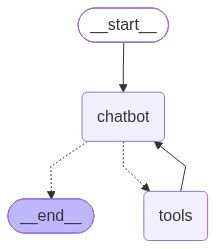

In [25]:
from langgraph.graph import END, START, StateGraph

# 1. Builder 생성
workflow = StateGraph(State)

# 2. Node 등록
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 3. Edge 연결
workflow.add_edge(START, "chatbot")
workflow.add_edge("tools","chatbot")

# 4. add_conditional_edges(source, path, path_map)
workflow.add_conditional_edges(
    "chatbot", # 어떤 노드가 끝난 뒤 분기할 것인가?

    tools_condition, # 다음 목적지를 판단할 함수
    {
        "tools" : "tools", # tools_condition 반환 값에 따라서
        END : END,         # 연결될 실제 노드 매핑
    }
)

# 5. complie() : 실행 가능한 상태로 변경
graph = workflow.compile()
display(graph)

## 검색이 필요한 질문의 message 흐름 확인

`invoke(initial_state)`는 LLM을 한 번만 호출하는 메서드가 아니다. `START`부터 `END`까지 이동하며 조건에 따라 chatbot과 tools Node를 여러 번 실행한 뒤 최종 State를 반환한다.

검색이 한 번 실행되면 `messages`는 보통 다음 순서가 된다. 모델이 추가 검색을 요청하면 가운데 두 단계가 반복될 수 있다.

```text
HumanMessage
→ AIMessage(tool_calls: name·args·id)
→ ToolMessage(tool_call_id: 같은 id)
→ 최종 AIMessage(tool_calls: [])
```

전체 State에는 검색 본문과 응답 block도 들어 있다. 아래 코드는 경로를 쉽게 읽도록 message 종류, Tool 이름과 호출 ID만 `list[dict]`로 요약한다.


In [26]:
from langchain_core.messages import HumanMessage

def summarize_messages(messages: list[AnyMessage]) -> list[dict]:
    """message 본문을 제외하고 종류와 Tool 호출 연결 정보만 반환"""

    return [
        {
            "message_type": message.type,  # human·ai·tool 중 message 종류
            "tool_calls": [  # AIMessage가 요청한 Tool 이름과 호출 ID 목록
                {"name": tool_call["name"], "id": tool_call["id"]}
                for tool_call in getattr(message, "tool_calls", [])
            ],
            # ToolMessage가 아니면 연결할 호출 ID가 없으므로 None을 사용한다.
            "tool_call_id": getattr(message, "tool_call_id", None),
        }
        for message in messages
    ]

# 1. 입력 준비
user_input = "LangGraph의 Node와 Edge를 설명하고, 필요함녀 검색 Tool을 사용해줘"

initial_state = {
    "messages" : [HumanMessage(content=user_input)]
}

# 2. 실행 후 결과 반환 받기
final_state = graph.invoke(initial_state) # START -> END

# 3. 결과 출력
trace_summary = summarize_messages(final_state["messages"])
display(trace_summary)

has_tool_calls = True
has_tool_calls = True
has_tool_calls = False


[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_wxegUq5ndbS0nl4O7n8uVNph'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_wxegUq5ndbS0nl4O7n8uVNph'},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_wEbB9KztEWBGc1j77lgG61Jf'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_wEbB9KztEWBGc1j77lgG61Jf'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

## 최종 AIMessage의 content 구조 확인

마지막 `AIMessage`는 Tool 결과를 읽고 만든 최종 응답이다. Responses API에서는 응답을 다룰 때 다음 세 값을 구분해야 한다.

- `content`: 공급자가 반환한 원본 content이다. 문자열일 수도 있고 block 목록일 수도 있다.
- `content_blocks`: 공급자별 content를 공통 block 목록으로 정규화한 값이다. block의 종류와 구조를 확인할 때 사용한다.
- `text`: text block만 모은 문자열이다. 화면 렌더링이나 일반 문자열 처리를 할 때 사용한다.

아래 코드는 `content_blocks`에서 사용자에게 공개할 `type='text'` block의 `type`과 `text`만 선택한다.


In [27]:
final_message = final_state["messages"][-1]

public_content_block = [
    {
        "type" : block["type"],
        "text": block.get("text" , "")
    }

    for block in final_message.content_blocks
    if block.get("type") == "text"
]

print(public_content_block)

[{'type': 'text', 'text': 'LangGraph에서 **Node(노드)**와 **Edge(엣지)**는 상태 기반 워크플로를 구성하는 핵심 요소입니다.\n\n> 한 줄 요약: **Node가 작업을 수행하고, Edge가 다음에 실행할 Node를 결정합니다.**\n\n공식 문서 기준으로 LangGraph는 `StateGraph`에 노드와 엣지를 추가한 뒤 `compile()`하여 실행 가능한 그래프로 만듭니다.  \n참고: [LangGraph Graph API 공식 문서](https://docs.langchain.com/oss/python/langgraph/use-graph-api)\n\n---\n\n## 1. LangGraph의 전체 구조\n\n일반적인 LangGraph 흐름은 다음과 같습니다.\n\n```text\nSTART\n  ↓\nNode A\n  ↓\nNode B\n  ↓\nEND\n```\n\n각 Node는 공유 상태(`State`)를 읽고, 필요한 값을 변경합니다. Edge는 Node 사이의 실행 순서를 연결합니다.\n\n```python\nfrom typing_extensions import TypedDict\nfrom langgraph.graph import StateGraph, START, END\n\n\nclass State(TypedDict):\n    question: str\n    answer: str\n\n\ndef process_question(state: State):\n    return {\n        "answer": f"질문을 처리했습니다: {state[\'question\']}"\n    }\n\n\nbuilder = StateGraph(State)\n\nbuilder.add_node("process_question", process_question)\n\nbuilder.add_edge(START, "process_question")\nbuilder.add_edge("process_question", 

## Tool이 필요 없는 질문의 짧은 경로

같은 그래프라도 모델이 `tool_calls`를 만들지 않으면 Tool Node를 거치지 않는다. 일반적인 의견 질문을 넣어 `START → chatbot → END`의 짧은 경로와 앞의 반복 경로를 비교한다.

모델의 Tool 선택은 확률적일 수 있으므로 질문 문장만 보고 경로를 단정하지 않고, 마지막 `AIMessage.tool_calls`와 분기 로그를 확인한다.


In [29]:
user_input = "AI가 인간의 삶을 어떻게 변화 시킬지 마크다운 형식으로 정리해줘"

initial_state = {
    "messages" : [HumanMessage(content=user_input)]
}

final_state = graph.invoke(initial_state)

trace_summary=summarize_messages(final_state["messages"])
print(trace_summary)

has_tool_calls = False
[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None}, {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]


## 최종 텍스트를 Markdown으로 렌더링하기

`Markdown()`은 문자열을 받아 제목·목록 같은 Markdown 문법을 화면에 렌더링한다. 원본 `AIMessage.content`는 block 목록일 수 있으므로 문자열 인자가 필요한 곳에 그대로 전달하지 않는다.

앞에서 구분한 `AIMessage.text`를 사용하면 State와 원본 content 구조는 유지하면서 사용자에게 보여 줄 텍스트만 문자열로 꺼낼 수 있다.


In [31]:
from IPython.display import Markdown

answer_text = final_state["messages"][-1].text
Markdown(answer_text)

# AI가 인간의 삶을 어떻게 변화시킬까?

인공지능(AI)은 이미 업무, 교육, 의료, 교통, 문화 등 다양한 분야에 영향을 주고 있습니다. 앞으로는 단순한 도구를 넘어 인간의 의사결정과 생활 방식 전반을 바꾸는 기술이 될 가능성이 큽니다.

## 1. 일과 직업의 변화

### 긍정적인 변화

- 반복적이고 위험한 업무를 AI와 로봇이 대신할 수 있음
- 문서 작성, 자료 분석, 고객 응대 등의 업무 효율 향상
- 개인의 능력을 보조하는 AI 비서와 협업 도구 확산
- 새로운 직업과 산업 등장
  - AI 개발자
  - 데이터 분석가
  - AI 윤리 전문가
  - 프롬프트 엔지니어
  - AI 교육 전문가

### 예상되는 문제

- 일부 직업이 자동화되어 일자리가 감소할 수 있음
- 업무 능력의 격차가 커질 가능성
- AI를 활용할 수 있는 사람과 그렇지 못한 사람 사이의 격차 확대
- 인간의 창의성보다 생산성과 효율성이 지나치게 중시될 위험

> 앞으로는 AI와 경쟁하기보다 AI를 활용하고 관리하는 능력이 중요한 역량이 될 것입니다.

---

## 2. 교육의 변화

AI는 학생과 교사에게 맞춤형 학습 환경을 제공할 수 있습니다.

### 주요 변화

- 학생별 수준과 학습 속도에 맞춘 개인 교사 역할
- 질문에 즉시 답변하고 부족한 부분을 반복 설명
- 외국어 회화, 글쓰기, 코딩 등 실습 중심 학습 지원
- 교사의 수업 준비와 학생 평가 업무 보조
- 장애 학생을 위한 음성·문자·번역 보조

### 주의할 점

- 학생이 AI 답변을 그대로 복사하는 문제
- 스스로 생각하고 문제를 해결하는 능력 약화
- 잘못된 정보나 편향된 답변을 학습할 가능성
- 교육의 질이 AI 도구에 대한 접근성에 따라 달라질 수 있음

---

## 3. 의료와 건강 관리의 변화

AI는 질병의 예방과 진단, 치료 과정에서 중요한 역할을 할 수 있습니다.

### 기대되는 효과

- 의료 영상 분석을 통한 질병 조기 발견
- 환자의 건강 데이터를 바탕으로 한 맞춤형 치료
- 신약 개발 기간과 비용 단축
- 웨어러블 기기를 활용한 실시간 건강 관리
- 의료 서비스가 부족한 지역에서 원격 진료 보조

### 해결해야 할 과제

- 의료 데이터의 개인정보 보호
- AI의 오진에 대한 책임 문제
- 환자의 상태를 데이터만으로 판단할 때 발생하는 한계
- 경제적 여건에 따른 의료 서비스 격차

---

## 4. 일상생활의 변화

AI는 개인 비서처럼 일상적인 업무를 도와줄 수 있습니다.

### 활용 사례

- 일정 관리와 자동 알림
- 개인 맞춤형 쇼핑 및 식단 추천
- 실시간 통역과 번역
- 스마트홈 기기 제어
- 여행 일정과 교통편 계획
- 노인과 장애인을 위한 생활 보조
- 개인 취향에 맞춘 음악·영상·콘텐츠 추천

앞으로는 AI가 사용자의 습관과 선호도를 학습하여 더욱 자연스럽게 생활을 지원할 가능성이 높습니다.

---

## 5. 인간관계와 소통의 변화

### 긍정적인 측면

- 언어 장벽이 낮아져 국제적 소통이 쉬워짐
- 외로움을 느끼는 사람에게 대화와 정서적 지원 제공
- 가족과 친구에게 보내는 메시지나 편지 작성 지원
- 소통이 어려운 사람의 의사 표현 보조

### 부정적인 측면

- 사람보다 AI와 대화하는 시간이 늘어날 수 있음
- 인간관계가 피상적으로 변할 가능성
- AI가 만든 가짜 영상과 음성으로 인한 사기와 혼란
- 감정적으로 AI에 과도하게 의존할 위험

AI는 인간관계를 대신하기보다는 인간 사이의 소통을 돕는 방향으로 활용되는 것이 바람직합니다.

---

## 6. 경제와 사회의 변화

AI는 생산성과 경제 구조를 크게 변화시킬 수 있습니다.

### 예상되는 변화

- 기업의 생산성과 업무 처리 속도 향상
- 제품과 서비스의 개인 맞춤화
- 소규모 기업과 개인 창업자의 경쟁력 강화
- 새로운 시장과 산업의 등장
- 국가 간 기술 경쟁 심화

### 사회적 위험

- AI 기술을 가진 기업과 그렇지 못한 기업 간 격차 확대
- 부의 집중과 소득 불평등 심화
- 개인정보를 활용한 과도한 감시
- 알고리즘에 의한 차별과 편견
- AI를 이용한 사이버 공격과 범죄 증가

---

## 7. 창의성과 문화의 변화

AI는 글, 음악, 이미지, 영상 등 다양한 창작 활동에 활용되고 있습니다.

### 긍정적인 변화

- 누구나 쉽게 콘텐츠를 제작할 수 있음
- 창작 과정의 시간과 비용 절감
- 새로운 예술 형식과 표현 방식 등장
- 아이디어를 빠르게 시각화하고 실험 가능

### 논쟁이 되는 부분

- AI가 만든 작품의 저작권 문제
- 기존 창작자의 일자리와 수입 감소
- 인간 창작과 AI 창작의 경계 모호
- 비슷한 스타일의 콘텐츠가 대량 생산될 가능성

앞으로는 인간의 경험, 감정, 가치관과 AI의 생성 능력이 결합된 새로운 형태의 문화가 발전할 것입니다.

---

## 8. 환경과 도시의 변화

AI는 에너지와 자원의 효율적인 사용에도 활용될 수 있습니다.

### 활용 분야

- 전력 수요 예측과 에너지 절약
- 교통량 분석을 통한 교통 체증 완화
- 농업 생산량과 기후 변화 예측
- 재난 발생 예측 및 대피 지원
- 공장과 건물의 에너지 관리
- 기후 데이터 분석과 환경 오염 감시

다만 AI를 운영하는 데이터센터 역시 많은 전력과 물을 필요로 하므로, AI의 환경 비용도 함께 고려해야 합니다.

---

## 9. 인간의 능력과 가치에 대한 변화

AI가 많은 지적 작업을 수행하게 되면 인간에게 요구되는 능력도 달라질 수 있습니다.

### 더욱 중요해질 능력

- 비판적 사고
- 창의적 문제 해결
- 공감과 의사소통
- 윤리적 판단
- 다양한 분야를 연결하는 능력
- AI 결과를 검증하는 능력
- 변화에 적응하고 계속 배우는 능력

AI가 정보를 빠르게 처리하더라도, 무엇이 중요한지 판단하고 어떤 방향으로 사용할지는 여전히 인간의 역할입니다.

---

## 10. 우리가 준비해야 할 과제

AI의 혜택을 누리기 위해서는 다음과 같은 준비가 필요합니다.

1. **AI 리터러시 교육 강화**
   - AI의 원리와 한계를 이해해야 함
2. **개인정보 보호**
   - 민감한 정보를 AI에 무분별하게 입력하지 않기
3. **결과 검증 습관**
   - AI의 답변을 항상 사실과 비교하기
4. **윤리와 법 제도 마련**
   - 차별, 저작권, 책임 문제에 대한 기준 필요
5. **직업 전환 지원**
   - 자동화로 영향을 받는 사람들에게 재교육 제공
6. **인간 중심의 활용**
   - 효율성뿐 아니라 인간의 존엄성과 안전을 고려

---

## 결론

AI는 인간의 삶을 더욱 편리하고 효율적으로 만들 수 있지만, 동시에 일자리 감소, 개인정보 침해, 불평등, 인간관계 약화와 같은 문제를 일으킬 수도 있습니다.

결국 AI가 인간의 삶을 어떻게 변화시킬지는 기술 자체보다 **인간이 AI를 어떤 목적과 기준으로 사용하는가**에 달려 있습니다. AI를 인간을 대체하는 수단이 아니라 인간의 능력을 확장하고 더 나은 사회를 만드는 도구로 활용하는 것이 중요합니다.

## 직접 구현을 prebuilt 구성 요소로 교체하기

앞에서는 Tool 요청과 결과의 연결 원리를 보기 위해 Tool Node와 route function을 직접 구현했다. 실제 프로젝트에서는 LangGraph가 제공하는 prebuilt 구성 요소로 같은 역할을 짧게 구성할 수 있다.

### 직접 구현

- `name·args·id → Tool 실행 → ToolMessage` 변환을 코드로 확인하기 좋다.
- 입력 검증과 예외 처리 범위를 직접 정해야 한다.

### prebuilt 구현

- `PrebuiltToolNode`: 마지막 `AIMessage.tool_calls`를 실행하고 같은 ID의 `ToolMessage`를 반환한다. 병렬 Tool 호출과 오류 처리도 지원한다.
- `prebuilt_tools_condition`: 마지막 message에 요청이 있으면 `"tools"`, 없으면 `"__end__"`를 반환한다.

두 반환값이 이미 등록한 `tools` Node와 LangGraph 종료 지점의 이름이므로 이 셀에서는 별도 `path_map`을 생략한다.


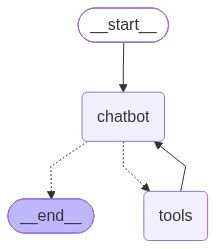

In [33]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode as PrebuiltToolNode
from langgraph.prebuilt import tools_condition as prebuilt_tools_condition

prebuilt_tools_node = PrebuiltToolNode(tools)

prebuilt_workflow = StateGraph(State)
prebuilt_workflow.add_node("chatbot", chatbot)
prebuilt_workflow.add_node("tools", prebuilt_tools_node) # Tool 노드 등록

prebuilt_workflow.add_edge(START, "chatbot")
prebuilt_workflow.add_edge("tools", "chatbot")

prebuilt_workflow.add_conditional_edges(
    'chatbot',
    prebuilt_tools_condition # Tool 요청 유무로 다음 노드 판별하는 함수
)

prebuilt_graph = prebuilt_workflow.compile()
prebuilt_graph

In [36]:
user_input = "LangGraph PreBuilt에 대해서 검색 Tool 사용해서 세 문장으로 알려줘"

initial_state={
    "messages":[HumanMessage(content=user_input)]
}

final_state = prebuilt_graph.invoke(initial_state)
trace_summary=summarize_messages(final_state["messages"])
display(trace_summary)

Markdown(final_state["messages"][-1].text)

[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_ZXzm6XXmOxa1g0XyTaR8rQKa'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_ZXzm6XXmOxa1g0XyTaR8rQKa'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

LangGraph Prebuilt는 도구 호출형 에이전트처럼 자주 사용하는 그래프 구조를 미리 구현해, 복잡한 오케스트레이션 코드를 직접 작성하지 않고도 빠르게 사용할 수 있게 해주는 기능입니다.  
대표적으로 `create_react_agent`가 있었지만 LangGraph v1에서는 deprecated되었으며, 현재는 LangChain의 `create_agent` 사용이 권장됩니다([공식 문서](https://docs.langchain.com/oss/python/releases/langgraph-v1)).  
LangGraph 자체는 사전 구축 기능보다 지속 실행, 스트리밍, 장기 메모리, Human-in-the-loop 같은 에이전트 오케스트레이션과 사용자 정의 워크플로 제어에 초점을 둡니다([개요](https://docs.langchain.com/oss/python/langgraph/overview)).